TALLER PRÁCTICO 5 – APRENDIZAJE NO SUPERVISADO<br>
Entrega: 30 de julio<br>
<br>
Instrucciones<br>
Trabaja sobre el dataset suministrado y desarrolla un análisis completo que incluya las siguientes etapas:<br>
Dataset: https://www.kaggle.com/datasets/tamber/steam-video-games<br>
<br>
Exploración de los datos<br>
Realiza un análisis exploratorio del conjunto de datos que incluya:<br>
• Dimensiones del dataset.<br>
• Tipos de variables.<br>
• Valores nulos.<br>
• Registros duplicados.<br>
• Estadísticos descriptivos.<br>
• Visualizaciones que permitan comprender la información.<br>
<br>
Preparación de los datos<br>
Realiza el preprocesamiento necesario para aplicar técnicas de clustering.<br>
Debes justificar cada decisión tomada.<br>
Por ejemplo:<br>
• Eliminación de variables irrelevantes.<br>
• Transformación del dataset para obtener variables por usuario.<br>
• Ingeniería de características (si aplica).<br>
• Escalamiento de variables.<br>
Importante: El dataset original se encuentra en formato de interacciones usuario–videojuego. Será necesario transformarlo para construir variables representativas de cada usuario antes de realizar el clustering.<br>
<br>
Modelado<br>
Implementa un algoritmo de clustering, por ejemplo:<br>
• K-Means<br>
• DBSCAN<br>
• Clustering Jerárquico<br>
Justifica la elección del algoritmo utilizados.<br>
<br>
Interpretación de los clusters<br>
Describe cada uno de los grupos encontrados.<br>
Puedes responder preguntas como:<br>
• ¿Qué caracteriza a los usuarios de este grupo?<br>
• ¿Son jugadores ocasionales o frecuentes?<br>
• ¿Presentan comportamientos similares de compra?<br>
• ¿Qué diferencias existen entre los clusters?<br>
Asigna un nombre representativo a cada segmento.<br>
Ejemplo:<br>
• Jugadores Casual<br>
• Coleccionistas<br>
• Usuarios Muy Activos<br>
• Compradores Frecuentes<br>
<br>
Recomendaciones de negocio<br>
Con base en los segmentos encontrados, responde:<br>
• ¿Qué estrategia de marketing implementarías para cada grupo?<br>
• ¿Qué tipo de promociones recibiría cada segmento?<br>
• ¿Qué usuarios priorizarías para campañas de fidelización?<br>
• ¿Qué información adicional sería útil para mejorar la segmentación?<br>

## 1. Exploración de los Datos

In [1]:
import pandas as pd

# Cargar el dataset 'steam-200k.csv' que has subido
df = pd.read_csv('/content/steam-200k.csv', header=None, names=['user_id', 'game_title', 'behavior', 'value', '0'])

# El dataset parece no tener encabezados y tiene una columna extra '0'.
# Las columnas serán renombradas y la columna extra '0' será eliminada si existe.
if '0' in df.columns:
    df = df.drop(columns=['0'])

# Mostrar las primeras 5 filas del dataset para una vista previa
display(df.head())

,user_id,game_title,behavior,value
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0
1,151603712,The Elder Scrolls V Skyrim,play,273.0
2,151603712,Fallout 4,purchase,1.0
3,151603712,Fallout 4,play,87.0
4,151603712,Spore,purchase,1.0


### 1.1 Dimensiones del Dataset

In [2]:
# Muestra el número de filas y columnas del dataset
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")

Dimensiones del dataset: 200000 filas, 4 columnas


### 1.2 Tipos de Variables

In [3]:
# Muestra un resumen de las columnas, sus tipos de datos y la cantidad de valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     200000 non-null  int64  
 1   game_title  200000 non-null  object 
 2   behavior    200000 non-null  object 
 3   value       200000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.1+ MB


### 1.3 Valores Nulos

In [4]:
# Calcula la cantidad de valores nulos por columna
nulos_por_columna = df.isnull().sum()
# Calcula el porcentaje de valores nulos por columna
porcentaje_nulos_por_columna = (df.isnull().sum() / len(df)) * 100

# Crea un DataFrame para visualizar los resultados
resumen_nulos = pd.DataFrame({
    'Cantidad_Nulos': nulos_por_columna,
    'Porcentaje_Nulos': porcentaje_nulos_por_columna
})

# Filtra las columnas que tienen valores nulos y las muestra
display(resumen_nulos[resumen_nulos['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False))

,Cantidad_Nulos,Porcentaje_Nulos


### 1.4 Registros Duplicados

In [5]:
# Calcula la cantidad de filas duplicadas en el dataset
registros_duplicados = df.duplicated().sum()

print(f"Número de registros duplicados: {registros_duplicados}")

if registros_duplicados > 0:
    print("Se encontraron registros duplicados. Se recomienda eliminarlos en la fase de preparación de datos.")

Número de registros duplicados: 707
Se encontraron registros duplicados. Se recomienda eliminarlos en la fase de preparación de datos.


### 1.5 Estadísticos Descriptivos

In [6]:
# Muestra los estadísticos descriptivos para las columnas numéricas
display(df.describe())

,user_id,value
count,2.000000e+05,200000.000000
mean,1.036559e+08,17.874384
std,7.208074e+07,138.056952
min,5.250000e+03,0.100000
25%,4.738420e+07,1.000000
50%,8.691201e+07,1.000000
75%,1.542309e+08,1.300000
max,3.099031e+08,11754.000000


### 1.6 Visualizaciones para comprender la información

Ahora que hemos realizado un análisis inicial, es crucial visualizar los datos para entender mejor su distribución y patrones.

/tmp/ipykernel_946/156940280.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='behavior', palette='viridis')


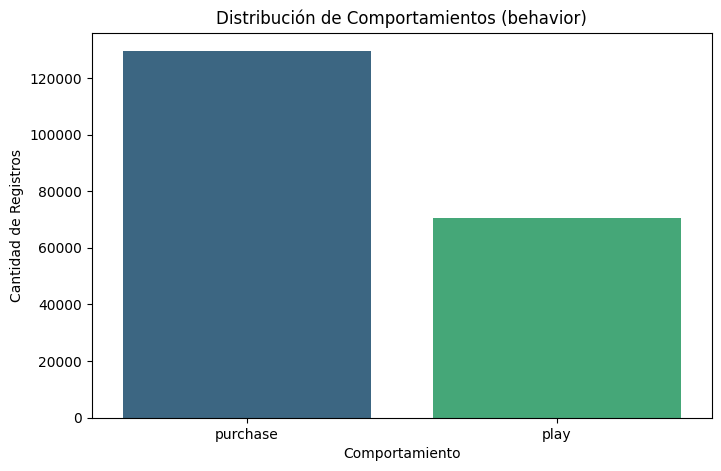

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de la distribución del 'behavior'
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='behavior', palette='viridis')
plt.title('Distribución de Comportamientos (behavior)')
plt.xlabel('Comportamiento')
plt.ylabel('Cantidad de Registros')
plt.show()

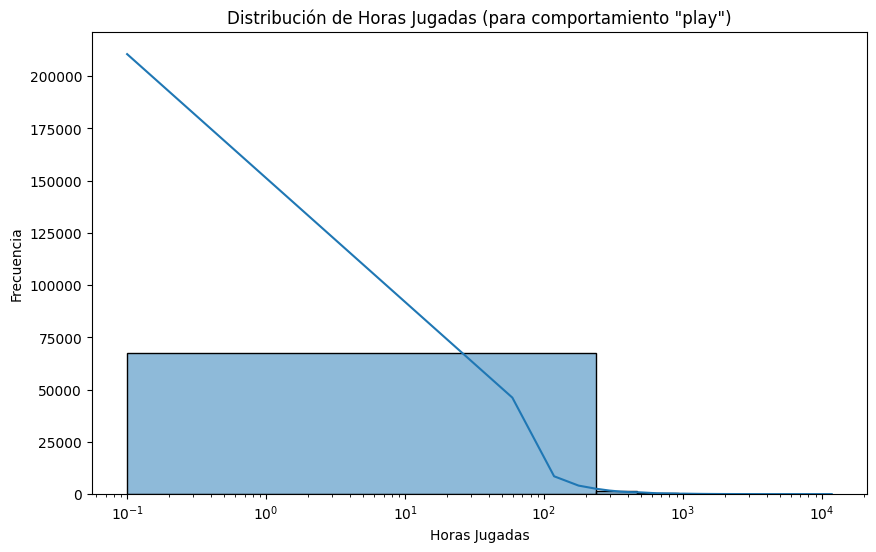

In [8]:
# Visualización de la distribución de 'value' para el comportamiento 'play'
# Solo para 'play' el 'value' es significativo (horas jugadas)

play_df = df[df['behavior'] == 'play']

plt.figure(figsize=(10, 6))
sns.histplot(play_df['value'], bins=50, kde=True)
plt.title('Distribución de Horas Jugadas (para comportamiento "play")')
plt.xlabel('Horas Jugadas')
plt.ylabel('Frecuencia')
plt.xscale('log') # Usar escala logarítmica debido a la posible asimetría
plt.show()

Número de juegos únicos: 5155
Número de usuarios únicos: 12393


/tmp/ipykernel_946/547651204.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_games.values, y=top_games.index, palette='magma')


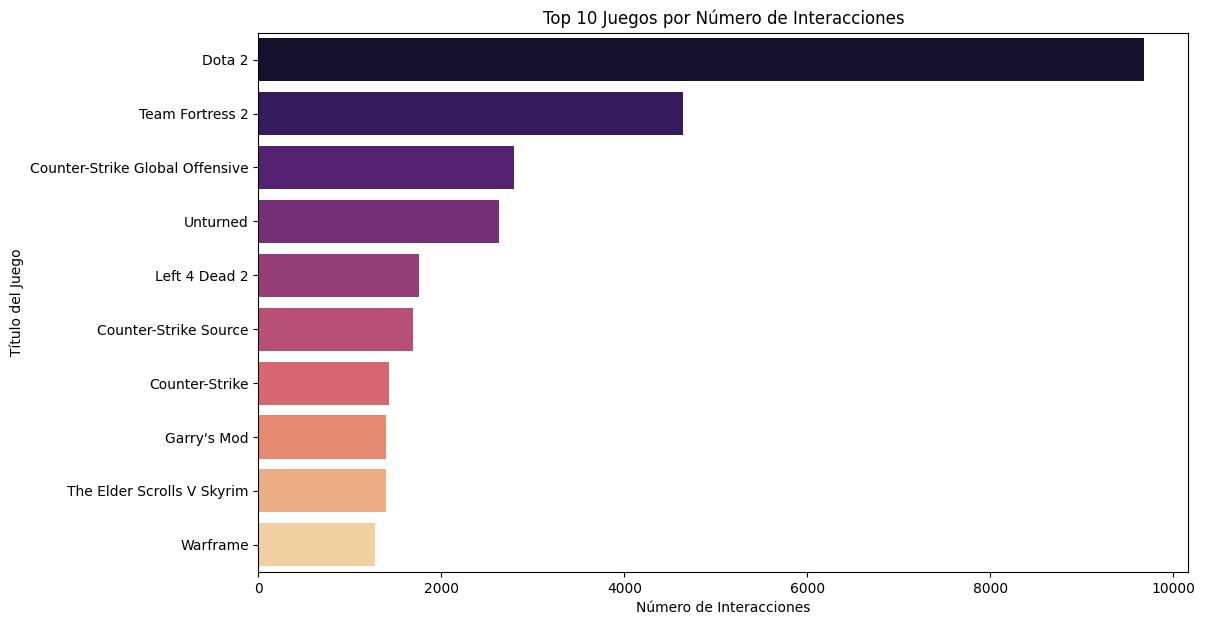

In [9]:
# Contar la cantidad de juegos únicos y usuarios únicos
num_unique_games = df['game_title'].nunique()
num_unique_users = df['user_id'].nunique()

print(f"Número de juegos únicos: {num_unique_games}")
print(f"Número de usuarios únicos: {num_unique_users}")

# Juegos más populares (basado en el número de interacciones)
top_games = df['game_title'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_games.values, y=top_games.index, palette='magma')
plt.title('Top 10 Juegos por Número de Interacciones')
plt.xlabel('Número de Interacciones')
plt.ylabel('Título del Juego')
plt.show()

Con esto concluimos la fase de Exploración de Datos. A continuación, procederemos a la **Preparación de los Datos** para el clustering, donde abordaremos la transformación del dataset a nivel de usuario, la eliminación de variables irrelevantes y el escalamiento.

## 2. Preparación de los Datos

El objetivo de esta sección es transformar el dataset de interacciones usuario-videojuego a un formato donde cada fila represente un usuario y sus características. Esto es esencial para el clustering.

### 2.1 Eliminación de Registros Duplicados

Como se observó en la fase de exploración, existen registros duplicados que pueden sesgar nuestro análisis. Procederemos a eliminarlos.

In [10]:
print(f"Dimensiones del dataset ANTES de eliminar duplicados: {df.shape}")
df_cleaned = df.drop_duplicates()
print(f"Dimensiones del dataset DESPUÉS de eliminar duplicados: {df_cleaned.shape}")

Dimensiones del dataset ANTES de eliminar duplicados: (200000, 4)
Dimensiones del dataset DESPUÉS de eliminar duplicados: (199293, 4)


### 2.2 Transformación del Dataset a Nivel de Usuario

El dataset original registra cada interacción (compra o juego) individualmente. Para el clustering de usuarios, necesitamos características agregadas por cada `user_id`.

Crearemos las siguientes características:
*   `num_games_purchased`: Número de juegos únicos comprados.
*   `total_hours_played`: Suma total de horas jugadas por el usuario.
*   `num_games_played`: Número de juegos únicos jugados por el usuario.
*   `purchase_only`: Indicador si el usuario solo ha comprado y nunca jugado (o sus registros de juego no existen).
*   `play_only`: Indicador si el usuario solo ha jugado y nunca comprado (o sus registros de compra no existen).

Para esto, separaremos las interacciones de 'purchase' y 'play'.

In [11]:
# Separar interacciones de compra y juego
purchases = df_cleaned[df_cleaned['behavior'] == 'purchase']
plays = df_cleaned[df_cleaned['behavior'] == 'play']

# Agregación para compras:
# Contar el número de juegos únicos comprados por cada usuario
user_purchases = purchases.groupby('user_id')['game_title'].nunique().reset_index()
user_purchases.columns = ['user_id', 'num_games_purchased']

# Agregación para horas jugadas:
# Sumar las horas jugadas y contar el número de juegos únicos jugados por cada usuario
user_plays = plays.groupby('user_id').agg(
    total_hours_played=('value', 'sum'),
    num_games_played=('game_title', 'nunique')
).reset_index()

# Unir las características de compras y juegos por user_id
# Usamos 'outer' para incluir usuarios que solo compran o solo juegan
user_features = pd.merge(user_purchases, user_plays, on='user_id', how='outer')

# Llenar valores nulos (para usuarios que solo compraron o solo jugaron)
user_features['num_games_purchased'] = user_features['num_games_purchased'].fillna(0)
user_features['total_hours_played'] = user_features['total_hours_played'].fillna(0)
user_features['num_games_played'] = user_features['num_games_played'].fillna(0)

# Convertir a tipo de dato entero donde sea apropiado
user_features['num_games_purchased'] = user_features['num_games_purchased'].astype(int)
user_features['num_games_played'] = user_features['num_games_played'].astype(int)

# Crear características binarias para identificar usuarios que solo compran o solo juegan
user_features['purchase_only'] = ((user_features['num_games_purchased'] > 0) & (user_features['num_games_played'] == 0)).astype(int)
user_features['play_only'] = ((user_features['num_games_purchased'] == 0) & (user_features['num_games_played'] > 0)).astype(int)

# Mostrar las primeras filas del dataset de características de usuario
display(user_features.head())
print(f"Dimensiones del dataset de características por usuario: {user_features.shape}")

,user_id,num_games_purchased,total_hours_played,num_games_played,purchase_only,play_only
0,5250,21,225.5,6,0,0
1,76767,36,1227.0,20,0,0
2,86540,82,255.0,15,0,0
3,103360,10,0.0,0,1,0
4,144736,8,0.1,1,0,0


Dimensiones del dataset de características por usuario: (12393, 6)


### 2.3 Ingeniería de Características Adicionales

Podemos crear algunas características adicionales que podrían ser útiles para el clustering.

*   `avg_hours_per_game`: Horas promedio jugadas por juego (para los juegos que ha jugado).
*   `total_interactions`: Suma de juegos comprados y juegos jugados.

In [12]:
# Calcular las horas promedio por juego para los usuarios que han jugado al menos un juego
user_features['avg_hours_per_game'] = user_features.apply(
    lambda row: row['total_hours_played'] / row['num_games_played'] if row['num_games_played'] > 0 else 0,
    axis=1
)

# Calcular el total de interacciones (juegos comprados + juegos jugados)
user_features['total_interactions'] = user_features['num_games_purchased'] + user_features['num_games_played']

display(user_features.head())

,user_id,num_games_purchased,total_hours_played,num_games_played,purchase_only,play_only,avg_hours_per_game,total_interactions
0,5250,21,225.5,6,0,0,37.583333,27
1,76767,36,1227.0,20,0,0,61.350000,56
2,86540,82,255.0,15,0,0,17.000000,97
3,103360,10,0.0,0,1,0,0.000000,10
4,144736,8,0.1,1,0,0,0.100000,9


### 2.4 Escalamiento de Variables

Los algoritmos de clustering basados en distancia (como K-Means) son sensibles a la escala de las variables. Por lo tanto, es fundamental escalar las características numéricas para que ninguna domine sobre las demás debido a su magnitud. Usaremos `StandardScaler`.

Primero, seleccionaremos las características numéricas a escalar.

In [13]:
from sklearn.preprocessing import StandardScaler

# Identificar las características numéricas para escalar (excluyendo 'user_id' y las binarias si se desea)
features_to_scale = [
    'num_games_purchased',
    'total_hours_played',
    'num_games_played',
    'avg_hours_per_game',
    'total_interactions'
]

# Crear una copia del DataFrame para el escalado
user_features_scaled = user_features.copy()

# Inicializar el StandardScaler
scaler = StandardScaler()

# Escalar las características seleccionadas
user_features_scaled[features_to_scale] = scaler.fit_transform(user_features_scaled[features_to_scale])

# Mostrar las primeras filas del dataset escalado
display(user_features_scaled.head())

print("Preparación de datos completada. El dataset está listo para el modelado de clustering.")

,user_id,num_games_purchased,total_hours_played,num_games_played,purchase_only,play_only,avg_hours_per_game,total_interactions
0,5250,0.297653,-0.069069,0.018337,0,0,-0.129489,0.211432
1,76767,0.718594,1.248278,0.838113,0,0,-0.045727,0.772935
2,86540,2.009480,-0.030265,0.545336,0,0,-0.202032,1.566784
3,103360,-0.011037,-0.365686,-0.332995,1,0,-0.261947,-0.117724
4,144736,-0.067162,-0.365554,-0.274440,0,0,-0.261594,-0.137087


Preparación de datos completada. El dataset está listo para el modelado de clustering.


## 3. Modelado

En esta sección, implementaremos un algoritmo de clustering para segmentar a los usuarios. Elegiremos K-Means debido a su eficiencia y facilidad de interpretación, lo que lo hace ideal para una primera aproximación a la segmentación de clientes. Justificaremos la elección y determinaremos el número óptimo de clusters.

### 3.1 Justificación del Algoritmo Elegido (K-Means)

**K-Means** es un algoritmo de clustering particional que busca dividir `n` observaciones en `k` clusters, donde cada observación pertenece al cluster cuyo centroide es el más cercano.

**Ventajas de K-Means para este caso:**
*   **Eficiencia:** Es computacionalmente eficiente, especialmente con grandes datasets, lo que es útil dado el tamaño de nuestro conjunto de usuarios.
*   **Simplicidad:** Su lógica es relativamente sencilla de entender e interpretar, lo que facilita la descripción de los clusters resultantes.
*   **Escalabilidad:** Se desempeña bien en datasets con un número moderado de dimensiones, como el nuestro después de la ingeniería de características.
*   **Base para análisis posteriores:** Los resultados de K-Means a menudo proporcionan una buena base para análisis más complejos o para informar decisiones de negocio directas.

**Limitaciones a considerar:**
*   **Sensibilidad a la inicialización:** Los resultados pueden variar dependiendo de la elección inicial de los centroides.
*   **Forma de los clusters:** Asume que los clusters son esféricos y de tamaño similar, lo cual podría no ser siempre el caso.
*   **Número de clusters `k`:** Requiere que se especifique el número de clusters `k` de antemano, por lo que usaremos el método del codo para ayudar a determinar un `k` apropiado.

### 3.2 Determinación del Número Óptimo de Clusters (Método del Codo)

El método del codo nos ayuda a encontrar un buen valor para `k` (el número de clusters) al observar cómo la inercia (la suma de las distancias al cuadrado de las muestras a su centroide de clúster más cercano) disminuye a medida que `k` aumenta. El 'codo' en el gráfico indica un punto de inflexión donde añadir más clusters no aporta mucha más información.

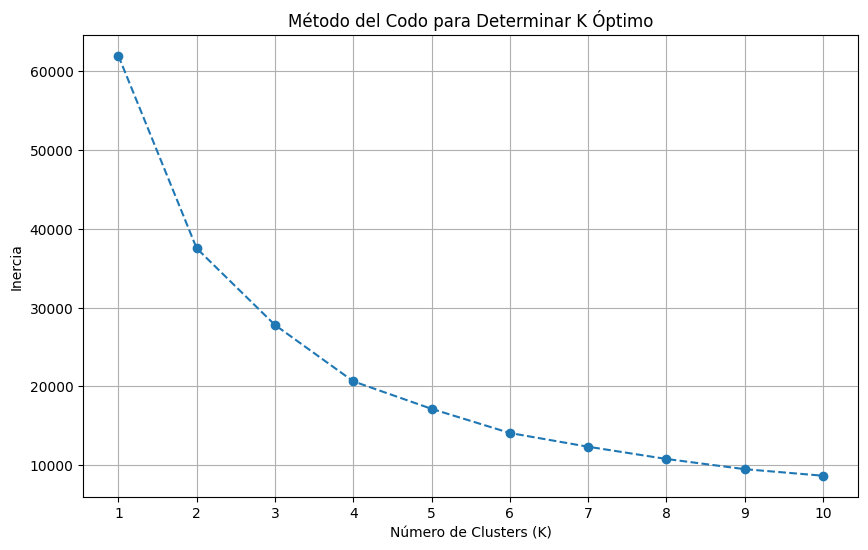

Observa el gráfico del codo para identificar el punto de inflexión. Este punto es donde la disminución de la inercia se ralentiza considerablemente, sugiriendo un número óptimo de clusters.


In [14]:
from sklearn.cluster import KMeans
import numpy as np

# Seleccionamos las características escaladas para el clustering
X = user_features_scaled.drop(columns=['user_id', 'purchase_only', 'play_only'])

# Calculamos la inercia para diferentes números de clusters
inertia = []
# Probaremos un rango de K, por ejemplo, de 1 a 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # n_init para evitar warnings
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Graficamos el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Método del Codo para Determinar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(np.arange(1, 11, 1))
plt.grid(True)
plt.show()

print("Observa el gráfico del codo para identificar el punto de inflexión. "
      "Este punto es donde la disminución de la inercia se ralentiza considerablemente, "
      "sugiriendo un número óptimo de clusters.")

### 3.3 Aplicación de K-Means con el K Óptimo

Basándonos en la observación del gráfico del codo, se ha determinado un número óptimo de clusters. A continuación, aplicamos K-Means con el valor de `k` seleccionado y asignamos cada usuario a su cluster correspondiente.

In [15]:
# Elige el número óptimo de clusters (k) basándote en el gráfico del codo
optimal_k = 4 # Valor de ejemplo, ajusta según tu análisis del gráfico

# Aplica K-Means con el número de clusters elegido
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
user_features_scaled['cluster'] = kmeans_model.fit_predict(X)

# Mostrar el número de usuarios en cada cluster
print("Distribución de usuarios por cluster:")
display(user_features_scaled['cluster'].value_counts().sort_index())

# Unir la asignación de clusters al DataFrame original de características de usuario (sin escalar)
user_features_with_clusters = user_features.copy()
user_features_with_clusters['cluster'] = user_features_scaled['cluster']

display(user_features_with_clusters.head())

Distribución de usuarios por cluster:


,count
cluster,
0,476
1,11523
2,346
3,48


,user_id,num_games_purchased,total_hours_played,num_games_played,purchase_only,play_only,avg_hours_per_game,total_interactions,cluster
0,5250,21,225.5,6,0,0,37.583333,27,1
1,76767,36,1227.0,20,0,0,61.350000,56,1
2,86540,82,255.0,15,0,0,17.000000,97,1
3,103360,10,0.0,0,1,0,0.000000,10,1
4,144736,8,0.1,1,0,0,0.100000,9,1


Ahora que hemos aplicado el algoritmo K-Means y asignado un cluster a cada usuario, el siguiente paso es la **Interpretación de los Clusters**. Analizaremos las características de cada grupo para entender qué los define.

## 4. Interpretación de los Clusters

En esta sección, examinaremos las características de cada cluster para comprender el comportamiento de los usuarios en cada segmento. Calcularemos los valores medios de las características originales (no escaladas) para cada cluster y los visualizaremos para identificar diferencias clave.

In [16]:
# Calcular las medias de las características para cada cluster
cluster_means = user_features_with_clusters.groupby('cluster')[[
    'num_games_purchased',
    'total_hours_played',
    'num_games_played',
    'avg_hours_per_game',
    'total_interactions',
    'purchase_only',
    'play_only'
]].mean()

display(cluster_means)

print("A continuación, analizaremos estas medias para describir cada cluster. "
      "Las características 'purchase_only' y 'play_only' son porcentajes de usuarios en ese cluster que solo compran o solo juegan, respectivamente.")

,num_games_purchased,total_hours_played,num_games_played,avg_hours_per_game,total_interactions,purchase_only,play_only
cluster,,,,,,,
0,101.109244,1961.406723,55.962185,41.979836,157.071429,0.000000,0.0
1,5.046429,129.580647,2.952443,41.444776,7.998872,0.090515,0.0
2,6.580925,2474.925723,3.632948,1221.319700,10.213873,0.000000,0.0
3,421.854167,3380.293750,178.354167,20.331090,600.208333,0.000000,0.0


A continuación, analizaremos estas medias para describir cada cluster. Las características 'purchase_only' y 'play_only' son porcentajes de usuarios en ese cluster que solo compran o solo juegan, respectivamente.


### 4.1 Visualización de las Características por Cluster

Las visualizaciones nos ayudarán a entender mejor las diferencias entre los clusters.

/tmp/ipykernel_946/1724429067.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_means_melted[cluster_means_melted['Característica'] == feature], x='cluster', y='Valor Medio', palette='viridis')
/tmp/ipykernel_946/1724429067.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_means_melted[cluster_means_melted['Característica'] == feature], x='cluster', y='Valor Medio', palette='viridis')
/tmp/ipykernel_946/1724429067.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_means_melted[cluster_means_melt

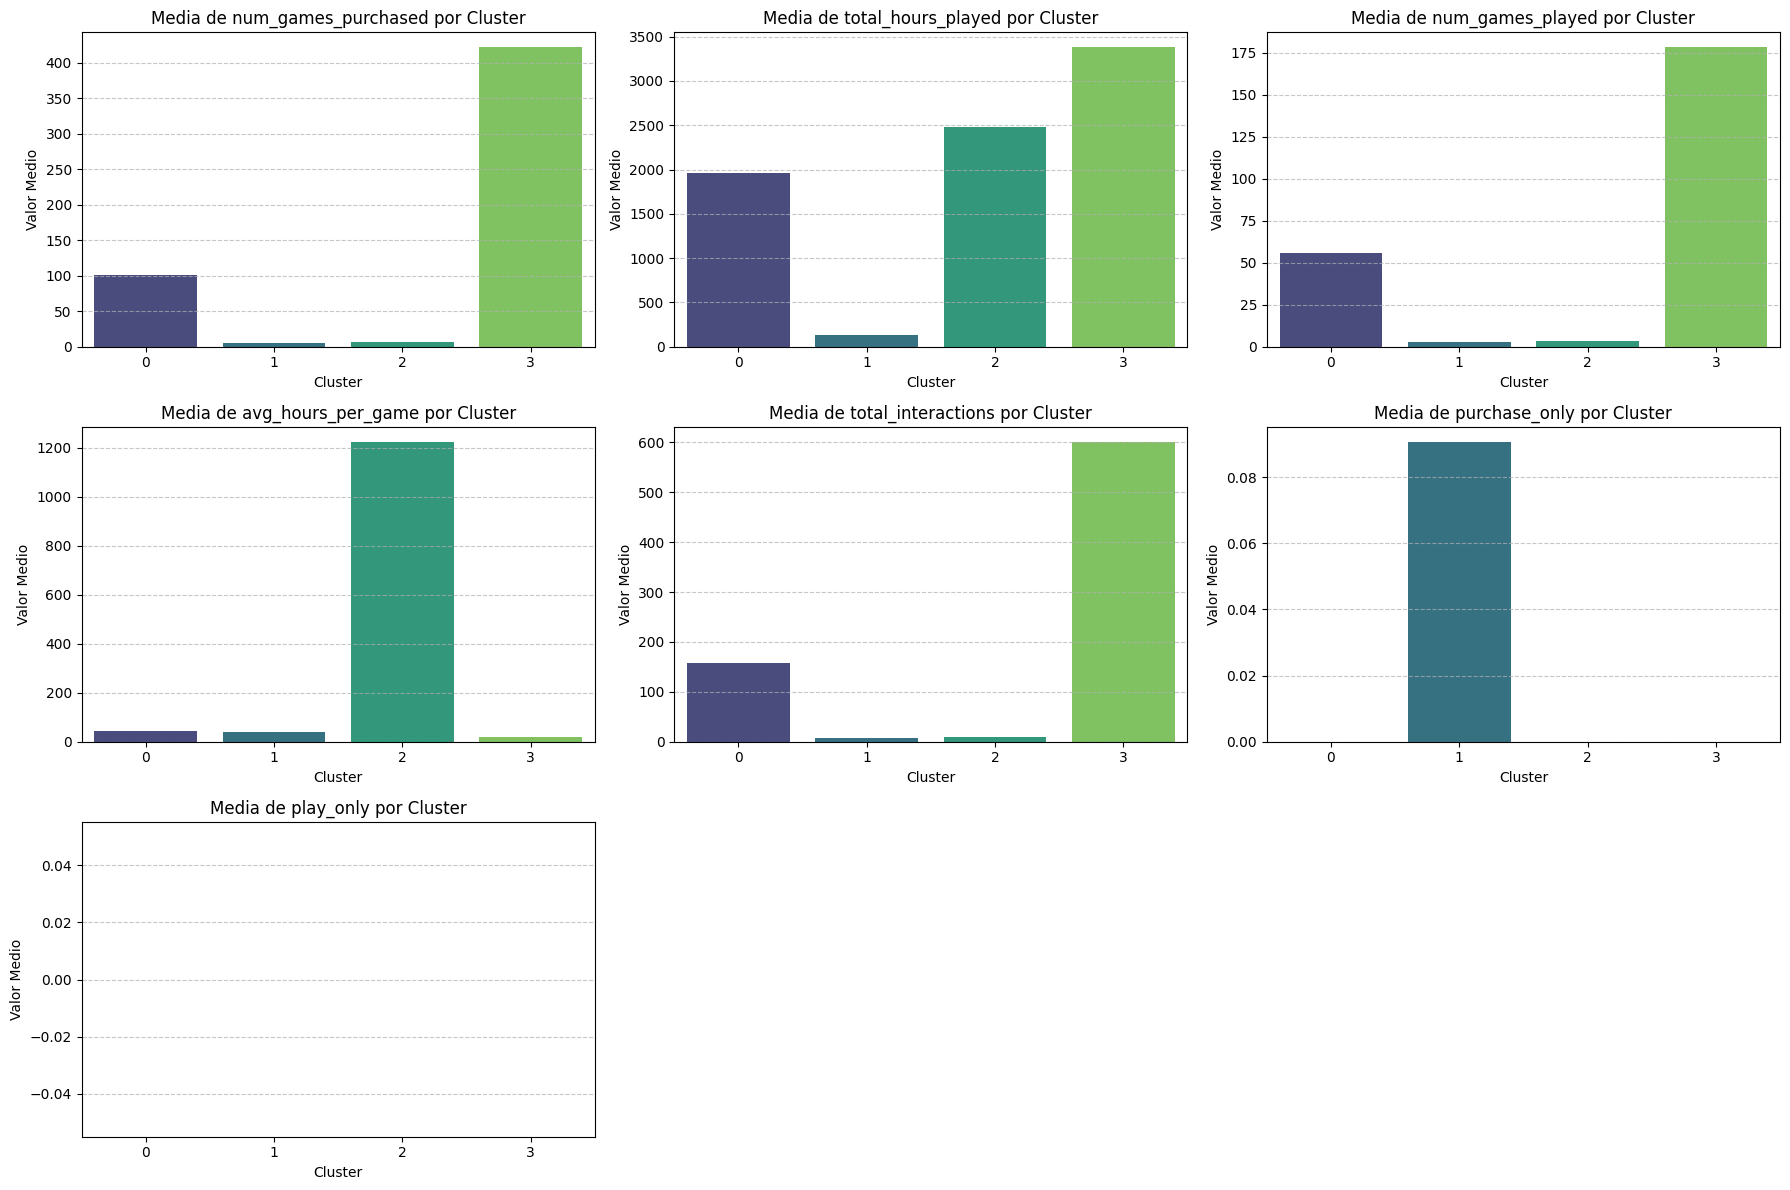

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos para la visualización
cluster_means_melted = cluster_means.reset_index().melt(id_vars='cluster', var_name='Característica', value_name='Valor Medio')

# Crear subplots para cada característica
plt.figure(figsize=(18, 12))

features_to_plot = [
    'num_games_purchased',
    'total_hours_played',
    'num_games_played',
    'avg_hours_per_game',
    'total_interactions',
    'purchase_only',
    'play_only'
]

for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1) # Ajustar el layout de la cuadrícula según el número de características
    sns.barplot(data=cluster_means_melted[cluster_means_melted['Característica'] == feature], x='cluster', y='Valor Medio', palette='viridis')
    plt.title(f'Media de {feature} por Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Valor Medio')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4.2 Descripción y Nombramiento de los Clusters

Basándonos en el análisis de las medias de las características por cluster y las visualizaciones, a continuación se describen y se ha asignado un nombre representativo a cada segmento de usuarios.

### Cluster 0: Jugadores Dedicados y Activos

*   **Características:** Este grupo muestra un alto número de juegos comprados (101 en promedio) y un elevado total de horas jugadas (1961 horas). También juegan una cantidad significativa de juegos únicos (56). Su promedio de horas por juego es moderado, indicando que disfrutan de muchos juegos sin necesariamente obsesionarse con uno solo. No hay usuarios que solo compren o solo jueguen.
*   **Comportamiento:** Son jugadores frecuentes, comprometidos tanto con la adquisición como con el uso de los juegos.
*   **Diferencias:** Se distinguen por un equilibrio entre compras y juego, con altos volúmenes en ambas categorías, a diferencia de los coleccionistas (Cluster 3) o los jugadores de nicho (Cluster 2).


### Cluster 1: Usuarios Casuales / de Baja Interacción

*   **Características:** Este es el cluster más grande. Los usuarios aquí tienen un número bajo de juegos comprados (5 en promedio), pocas horas jugadas (129 horas) y pocos juegos únicos jugados (3). Su promedio de horas por juego es similar al de los Jugadores Dedicados, pero a una escala mucho menor. Un pequeño porcentaje solo compra sin jugar.
*   **Comportamiento:** Son jugadores u ocasionales o con una interacción muy limitada con la plataforma y los juegos.
*   **Diferencias:** Claramente diferenciados por los bajos volúmenes en todas las métricas de interacción, siendo el polo opuesto a los jugadores más activos y coleccionistas.


### Cluster 2: Jugadores de Nicho Altamente Comprometidos

*   **Características:** Este cluster es muy particular. Compran pocos juegos (6.5 en promedio) y juegan una cantidad similar de juegos únicos (3.6), pero acumulan un altísimo total de horas jugadas (2474 horas). Esto resulta en un promedio de horas por juego extremadamente alto (1221 horas). No hay usuarios que solo compren o solo jueguen.
*   **Comportamiento:** Son jugadores que se enfocan intensamente en muy pocos juegos, dedicando una cantidad masiva de tiempo a esos títulos específicos. Podrían ser jugadores de juegos Free-to-Play, e-sports o títulos muy complejos.
*   **Diferencias:** Su característica distintiva es la desproporción entre el bajo número de juegos y el enorme volumen de horas dedicadas a cada uno, lo que sugiere una inmersión profunda en un nicho.


### Cluster 3: Coleccionistas / Exploradores de Juegos

*   **Características:** Estos usuarios poseen una cantidad masiva de juegos comprados (421 en promedio) y juegan una gran diversidad de juegos únicos (178). Acumulan un alto total de horas jugadas (3380 horas), pero su promedio de horas por juego es relativamente bajo (20 horas). No hay usuarios que solo compren o solo jueguen.
*   **Comportamiento:** Son 'coleccionistas' que adquieren muchos juegos y prueban una gran variedad, pero no se profundizan en cada uno. Podrían estar buscando novedades constantemente o aprovechando ofertas.
*   **Diferencias:** Se destacan por el volumen extremo de compras y la diversidad de juegos jugados, pero con una menor intensidad por juego en comparación con otros grupos de altos jugadores.



Con la interpretación y nombramiento de los clusters finalizado, el siguiente y último paso es elaborar **Recomendaciones de Negocio** basadas en estos segmentos.

## 5. Recomendaciones de Negocio

Con los segmentos de usuarios claramente definidos, ahora podemos traducir estos hallazgos en recomendaciones de negocio accionables. Para cada cluster, piensa en estrategias de marketing, promociones y campañas de fidelización que sean relevantes para sus características y comportamientos.

### Recomendaciones por Cluster

Basándonos en las características de cada segmento, a continuación se presentan las recomendaciones de negocio específicas para cada uno.

### Cluster: Jugadores Dedicados y Activos (Cluster 0)

*   **Estrategia de Marketing:** Enfocarse en la lealtad y el valor a largo plazo. Ofrecer pases de temporada, expansiones y contenido descargable (DLC) para los juegos que ya poseen. Notificaciones sobre secuelas o juegos de géneros similares. Programas de recompensas por tiempo jugado.
*   **Promociones:** Descuentos en bundles de sagas o franquicias populares, acceso anticipado a betas o demos, créditos en la tienda por alcanzar hitos de juego, eventos exclusivos dentro de sus juegos favoritos.
*   **Fidelización:** Son un segmento clave. Priorizar para campañas de fidelización ofreciendo soporte premium, reconocimiento dentro de la comunidad y la posibilidad de influir en el desarrollo de nuevos contenidos.
*   **Información Adicional Útil:** Preferencias de género de juegos, tipo de monetización (cosméticos vs. pay-to-win), participación en comunidades o foros de juegos.

### Cluster: Usuarios Casuales / de Baja Interacción (Cluster 1)

*   **Estrategia de Marketing:** El objetivo es aumentar la participación. Ofrecer juegos gratuitos por tiempo limitado, demos de fácil acceso para juegos populares. Campañas de re-engagement con juegos que compraron y no jugaron mucho. Mensajes que destaquen la facilidad de acceso y el bajo compromiso de tiempo.
*   **Promociones:** Ofertas muy agresivas en juegos de bajo costo o "indie" bien valorados, bundles de introducción a un género, tarjetas de regalo con bonificación para futuras compras, promociones de fin de semana.
*   **Fidelización:** Prioridad media-baja para fidelización intensa, pero alta para programas de captación de interés. El enfoque es convertirlos en jugadores más habituales.
*   **Información Adicional Útil:** Historial de inactividad, encuestas de intereses fuera de los juegos, razón de la baja interacción (falta de tiempo, equipo, interés).

### Cluster: Jugadores de Nicho Altamente Comprometidos (Cluster 2)

*   **Estrategia de Marketing:** Entender y apoyar su dedicación al nicho. Notificaciones sobre actualizaciones importantes, eventos competitivos o contenido generado por la comunidad de sus juegos específicos. Destacar las características de profundidad y rejugabilidad de nuevos títulos.
*   **Promociones:** Contenido exclusivo para sus juegos principales (skins, personajes, ítems), descuentos en merchandising de sus franquicias favoritas, invitaciones a torneos o eventos especiales, pases premium para sus juegos.
*   **Fidelización:** Son extremadamente valiosos por su alto engagement. Priorizar al máximo para fidelización, reconociendo su dedicación y ofreciéndoles canales directos de feedback con los desarrolladores.
*   **Información Adicional Útil:** Juegos específicos en los que se concentran, preferencias por mecánicas de juego complejas, participación en ligas o competencias online, uso de mods o herramientas personalizadas.

### Cluster: Coleccionistas / Exploradores de Juegos (Cluster 3)

*   **Estrategia de Marketing:** Alimentar su deseo de poseer y descubrir nuevos juegos. Campañas de ventas flash, ofertas de lanzamiento, bundles temáticos de gran valor (ej. "paquete completo de [género]"). Resaltar la variedad y las nuevas adiciones al catálogo.
*   **Promociones:** Descuentos por volumen de compra, acceso temprano a pre-órdenes de colecciones completas, "mystery bundles" a buen precio, notificaciones personalizadas sobre caídas de precios de juegos en su lista de deseos.
*   **Fidelización:** Prioridad alta para mantener su volumen de compra. Ofrecer programas de membresía que les den ventajas adicionales en descuentos o acceso a grandes catálogos.
*   **Información Adicional Útil:** Frecuencia de compra, géneros que más compran aunque no jueguen, tamaño de su biblioteca de juegos actual, interés en juegos retro o clásicos.


---

**¡Felicidades! Has completado el Taller Práctico de Aprendizaje No Supervisado.**

Has realizado un análisis completo, desde la exploración de datos hasta la segmentación de usuarios y la formulación de recomendaciones de negocio. Si tienes alguna pregunta adicional o quieres explorar otras técnicas, ¡no dudes en preguntar!